# Notebook 05 — Extended Evaluation

Curve analysis for the final candidate models **E09** (final model) and **E06** (alternative candidate).

- **Section 1**: Multiclass ROC curve (one curve per class + macro-average)
- **Section 2**: Multiclass Precision-Recall curve
- **Section 3**: Calibration curve (reliability diagram)
- **Section 4**: Comparative summary E06 vs E09
- **Section 5**: 95% Confidence Intervals (Bootstrap)
- **Section 6**: Baseline comparison — unimodal vs multimodal

Models evaluated:
- **E09** — Color Constancy + age + localization — seed 42 **!!! FINAL MODEL**
- **E06** — Color Constancy + sex — seed 42 (alternative candidate)

## Imports and configuration

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

sys.path.append(os.path.dirname(os.getcwd()))
from src.config import FIGURES_DIR

# Classes in fixed order (same as in config.py)
CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
N_CLASSES = len(CLASSES)

# Consistent colours with notebook 04
COLOR_E09 = '#2ecc71'
COLOR_E06 = '#f39c12'

print('Imports OK')
print(f'Classes: {CLASSES}')

Imports OK
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Load probabilities

In [3]:
PROBS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'outputs', 'probs')

# E09 — final model (seed 42)
e09_probs  = np.load(os.path.join(PROBS_DIR, 'prep_colorconstancy__meta_age+localization__seed_42_probs.npy'))
e09_labels = np.load(os.path.join(PROBS_DIR, 'prep_colorconstancy__meta_age+localization__seed_42_labels.npy'))

# E06 — alternative candidate (seed 42)
e06_probs  = np.load(os.path.join(PROBS_DIR, 'prep_colorconstancy__meta_sex__seed_42_probs.npy'))
e06_labels = np.load(os.path.join(PROBS_DIR, 'prep_colorconstancy__meta_sex__seed_42_labels.npy'))

# Binarise labels for one-vs-rest metrics
e09_labels_bin = label_binarize(e09_labels, classes=list(range(N_CLASSES)))
e06_labels_bin = label_binarize(e06_labels, classes=list(range(N_CLASSES)))

print(f'E09 — probs shape: {e09_probs.shape} | labels shape: {e09_labels.shape}')
print(f'E06 — probs shape: {e06_probs.shape} | labels shape: {e06_labels.shape}')
print(f'Test samples: {len(e09_labels)}')
print(f'Class distribution in test:')
for i, c in enumerate(CLASSES):
    print(f'  {c}: {(e09_labels == i).sum()}')

E09 — probs shape: (1503, 7) | labels shape: (1503,)
E06 — probs shape: (1503, 7) | labels shape: (1503,)
Test samples: 1503
Class distribution in test:
  akiec: 49
  bcc: 77
  bkl: 165
  df: 17
  mel: 167
  nv: 1006
  vasc: 22


## Section 1: Multiclass ROC curve

In [4]:
def compute_roc(probs, labels_bin):
    """Computes ROC curves per class and macro-average."""
    fpr, tpr, roc_auc = {}, {}, {}
    for i, cls in enumerate(CLASSES):
        fpr[cls], tpr[cls], _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc[cls] = auc(fpr[cls], tpr[cls])
    # Macro-average: interpolate all curves over a common grid
    all_fpr = np.unique(np.concatenate([fpr[c] for c in CLASSES]))
    mean_tpr = np.zeros_like(all_fpr)
    for cls in CLASSES:
        mean_tpr += np.interp(all_fpr, fpr[cls], tpr[cls])
    mean_tpr /= N_CLASSES
    fpr['macro'] = all_fpr
    tpr['macro'] = mean_tpr
    roc_auc['macro'] = auc(all_fpr, mean_tpr)
    return fpr, tpr, roc_auc

e09_fpr, e09_tpr, e09_roc_auc = compute_roc(e09_probs, e09_labels_bin)
e06_fpr, e06_tpr, e06_roc_auc = compute_roc(e06_probs, e06_labels_bin)

print('ROC-AUC per class:')
print(f'{"Class":<10} {"E09":>8} {"E06":>8} {"Δ(E09-E06)":>12}')
print('-' * 42)
for cls in CLASSES:
    delta = e09_roc_auc[cls] - e06_roc_auc[cls]
    marker = ' *' if cls == 'mel' else ''
    print(f'{cls:<10} {e09_roc_auc[cls]:>8.4f} {e06_roc_auc[cls]:>8.4f} {delta:>+12.4f}{marker}')
print('-' * 42)
print(f'{"macro":<10} {e09_roc_auc["macro"]:>8.4f} {e06_roc_auc["macro"]:>8.4f} {e09_roc_auc["macro"]-e06_roc_auc["macro"]:>+12.4f}')

ROC-AUC per class:
Class           E09      E06   Δ(E09-E06)
------------------------------------------
akiec        0.9767   0.9883      -0.0116
bcc          0.9912   0.9863      +0.0049
bkl          0.9465   0.9525      -0.0060
df           0.9918   0.9994      -0.0076
mel          0.9324   0.9252      +0.0072 *
nv           0.9565   0.9553      +0.0012
vasc         0.9995   0.9998      -0.0003
------------------------------------------
macro        0.9710   0.9727      -0.0017


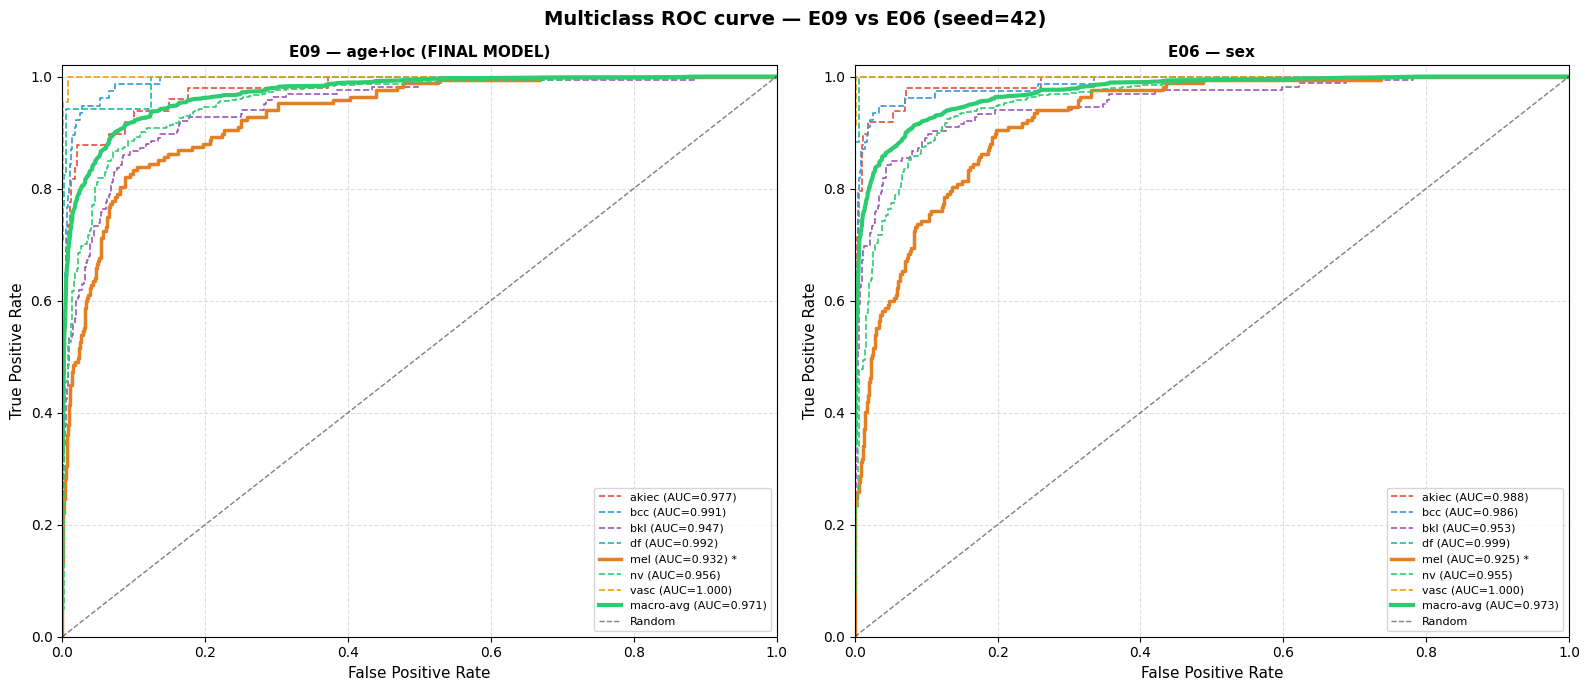

Figure saved.


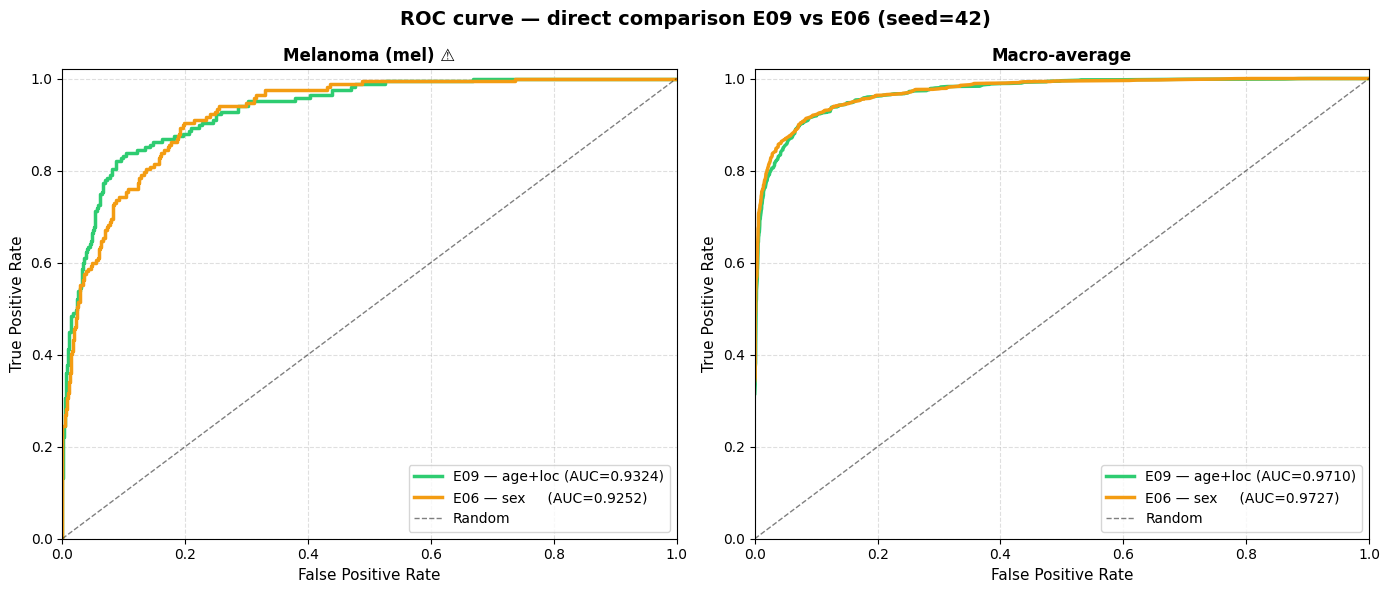

Figure saved.


In [5]:
# Consistent colour palette per class
CLASS_COLORS = {
    'akiec': '#e74c3c',
    'bcc':   '#3498db',
    'bkl':   '#9b59b6',
    'df':    '#1abc9c',
    'mel':   '#e67e22',
    'nv':    '#2ecc71',
    'vasc':  '#f39c12',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Multiclass ROC curve — E09 vs E06 (seed=42)', fontsize=14, fontweight='bold')

for ax, (model_name, fpr, tpr, roc_auc, color_macro) in zip(axes, [
    ('E09 — age+loc (FINAL MODEL)', e09_fpr, e09_tpr, e09_roc_auc, COLOR_E09),
    ('E06 — sex',                   e06_fpr, e06_tpr, e06_roc_auc, COLOR_E06),
]):
    for cls in CLASSES:
        lw = 2.5 if cls == 'mel' else 1.2
        ls = '-'  if cls == 'mel' else '--'
        label = f'{cls} (AUC={roc_auc[cls]:.3f})'
        if cls == 'mel':
            label += ' *'
        ax.plot(fpr[cls], tpr[cls], color=CLASS_COLORS[cls],
                lw=lw, linestyle=ls, label=label)

    # Macro-average
    ax.plot(fpr['macro'], tpr['macro'], color=COLOR_E09,
        lw=3, linestyle='-',
        label=f'macro-avg (AUC={roc_auc["macro"]:.3f})')

    # Reference diagonal
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curves_e09_vs_e06.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

# ── Direct comparison plots E09 vs E06 ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC curve — direct comparison E09 vs E06 (seed=42)',
             fontsize=14, fontweight='bold')

# Left plot: Melanoma only
axes[0].plot(e09_fpr['mel'], e09_tpr['mel'],
             color=COLOR_E09, lw=2.5,
             label=f'E09 — age+loc (AUC={e09_roc_auc["mel"]:.4f})')
axes[0].plot(e06_fpr['mel'], e06_tpr['mel'],
             color=COLOR_E06, lw=2.5,
             label=f'E06 — sex     (AUC={e06_roc_auc["mel"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.02])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Melanoma (mel) ⚠', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(linestyle='--', alpha=0.4)

# Right plot: Macro-average only
axes[1].plot(e09_fpr['macro'], e09_tpr['macro'],
             color=COLOR_E09, lw=2.5,
             label=f'E09 — age+loc (AUC={e09_roc_auc["macro"]:.4f})')
axes[1].plot(e06_fpr['macro'], e06_tpr['macro'],
             color=COLOR_E06, lw=2.5,
             label=f'E06 — sex     (AUC={e06_roc_auc["macro"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Macro-average', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'roc_comparison_mel_macro.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## Section 2: Multiclass Precision-Recall Curve

In [6]:
def compute_pr(probs, labels_bin):
    """Computes Precision-Recall curves per class and macro-average (mAP)."""
    precision, recall, ap = {}, {}, {}
    for i, cls in enumerate(CLASSES):
        precision[cls], recall[cls], _ = precision_recall_curve(labels_bin[:, i], probs[:, i])
        ap[cls] = average_precision_score(labels_bin[:, i], probs[:, i])
    ap['macro'] = np.mean([ap[c] for c in CLASSES])
    return precision, recall, ap

e09_prec, e09_rec, e09_ap = compute_pr(e09_probs, e09_labels_bin)
e06_prec, e06_rec, e06_ap = compute_pr(e06_probs, e06_labels_bin)

print('Average Precision (AP) per class:')
print(f'{"Class":<10} {"E09":>8} {"E06":>8} {"Δ(E09-E06)":>12}')
print('-' * 42)
for cls in CLASSES:
    delta = e09_ap[cls] - e06_ap[cls]
    marker = ' *' if cls == 'mel' else ''
    print(f'{cls:<10} {e09_ap[cls]:>8.4f} {e06_ap[cls]:>8.4f} {delta:>+12.4f}{marker}')
print('-' * 42)
print(f'{"mAP":<10} {e09_ap["macro"]:>8.4f} {e06_ap["macro"]:>8.4f} {e09_ap["macro"]-e06_ap["macro"]:>+12.4f}')

Average Precision (AP) per class:
Class           E09      E06   Δ(E09-E06)
------------------------------------------
akiec        0.7645   0.8511      -0.0866
bcc          0.8652   0.8838      -0.0186
bkl          0.7812   0.8289      -0.0477
df           0.8851   0.9616      -0.0764
mel          0.7184   0.6804      +0.0381 *
nv           0.9762   0.9749      +0.0013
vasc         0.9775   0.9901      -0.0126
------------------------------------------
mAP          0.8526   0.8815      -0.0289


Interesante, aquí la historia es más matizada que en ROC. E06 tiene mejor mAP global (0.8815 vs 0.8526), pero E09 gana donde más importa: melanoma AP 0.7184 vs 0.6804 (+0.038). 

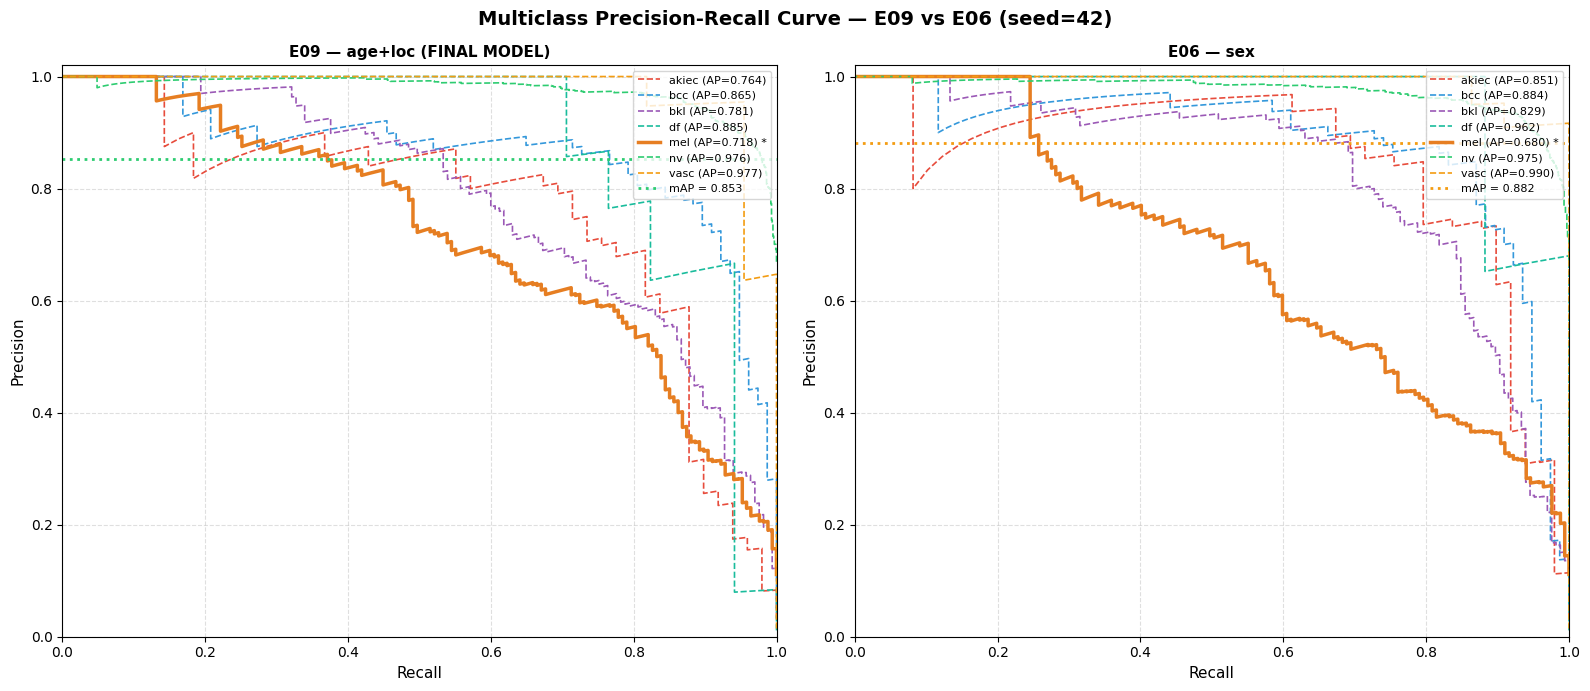

Figure saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Multiclass Precision-Recall Curve — E09 vs E06 (seed=42)', fontsize=14, fontweight='bold')

for ax, (model_name, prec, rec, ap, color_macro) in zip(axes, [
    ('E09 — age+loc (FINAL MODEL)', e09_prec, e09_rec, e09_ap, COLOR_E09),
    ('E06 — sex',                   e06_prec, e06_rec, e06_ap, COLOR_E06),
]):
    for cls in CLASSES:
        lw = 2.5 if cls == 'mel' else 1.2
        ls = '-'  if cls == 'mel' else '--'
        label = f'{cls} (AP={ap[cls]:.3f})'
        if cls == 'mel':
            label += ' *'
        ax.plot(rec[cls], prec[cls], color=CLASS_COLORS[cls],
                lw=lw, linestyle=ls, label=label)

    # mAP line
    ax.axhline(ap['macro'], color=color_macro, lw=2, linestyle=':',
               label=f'mAP = {ap["macro"]:.3f}')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pr_curves_e09_vs_e06.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

La curva de melanoma (naranja sólido) claramente por debajo del resto en ambos modelos, y se aprecia bien que E09 mantiene mejor precision a recalls altos en melanoma. 

## Section 3: Calibration Curve (Reliability Diagram)

In [8]:
from sklearn.metrics import brier_score_loss

def compute_calibration(probs, labels_bin, n_bins=10):
    """Computes calibration curves per class."""
    fraction_pos, mean_pred = {}, {}
    for i, cls in enumerate(CLASSES):
        fraction_pos[cls], mean_pred[cls] = calibration_curve(
            labels_bin[:, i], probs[:, i], n_bins=n_bins, strategy='uniform'
        )
    return fraction_pos, mean_pred

e09_frac, e09_mean = compute_calibration(e09_probs, e09_labels_bin)
e06_frac, e06_mean = compute_calibration(e06_probs, e06_labels_bin)

# Brier Score per class
print('Brier Score per class (lower is better):')
print(f'{"Class":<10} {"E09":>8} {"E06":>8} {"Δ(E09-E06)":>12}')
print('-' * 42)
e09_briers, e06_briers = [], []
for i, cls in enumerate(CLASSES):
    b09 = brier_score_loss(e09_labels_bin[:, i], e09_probs[:, i])
    b06 = brier_score_loss(e06_labels_bin[:, i], e06_probs[:, i])
    e09_briers.append(b09)
    e06_briers.append(b06)
    marker = ' *' if cls == 'mel' else ''
    print(f'{cls:<10} {b09:>8.4f} {b06:>8.4f} {b09-b06:>+12.4f}{marker}')
print('-' * 42)
print(f'{"mean":<10} {np.mean(e09_briers):>8.4f} {np.mean(e06_briers):>8.4f} {np.mean(e09_briers)-np.mean(e06_briers):>+12.4f}')

Brier Score per class (lower is better):
Class           E09      E06   Δ(E09-E06)
------------------------------------------
akiec        0.0166   0.0108      +0.0058
bcc          0.0161   0.0137      +0.0024
bkl          0.0504   0.0416      +0.0088
df           0.0035   0.0016      +0.0019
mel          0.0914   0.0831      +0.0083 *
nv           0.1177   0.1046      +0.0131
vasc         0.0029   0.0019      +0.0011
------------------------------------------
mean         0.0426   0.0367      +0.0059


 E06 tiene mejor Brier Score en todas las clases incluyendo melanoma. Esto es consistente con lo que ya sabíamos (E06 tiene mejor mAP global y mejor calibración), pero E09 sigue siendo el modelo final por estabilidad y Melanoma Recall. Esto hay que reflejarlo bien en las conclusiones.

* E06 tiene mejor Brier Score en todas las clases sin excepción — 
  las diferencias van desde +0.0011 (vasc) hasta +0.0131 (nv) 
  a favor de E06. La media global es 0.0367 (E06) vs 0.0426 (E09).

* El valor del Brier Score de mel en E09 (0.0914) que aparece en 
  la curva de calibración corresponde a la clase melanoma 
  específicamente, no a la media global.

* nv aparece por encima de la diagonal en ambos modelos — el modelo 
  subestima su probabilidad debido al weighted CE que penaliza 
  la clase dominante (Brier nv: 0.1177 en E09, el más alto de 
  todas las clases).

* mel aparece por debajo de la diagonal — el modelo sobreestima 
  ligeramente la confianza en melanoma (Brier mel: 0.0914 en E09), 
  comportamiento aceptable y conservador clínicamente.

* El Brier Score medio de E09 (0.0426) justifica el umbral de 
  incertidumbre del 70% en Streamlit: las probabilidades son 
  interpretables como confianza real pese a ser ligeramente 
  peor calibrado que E06.


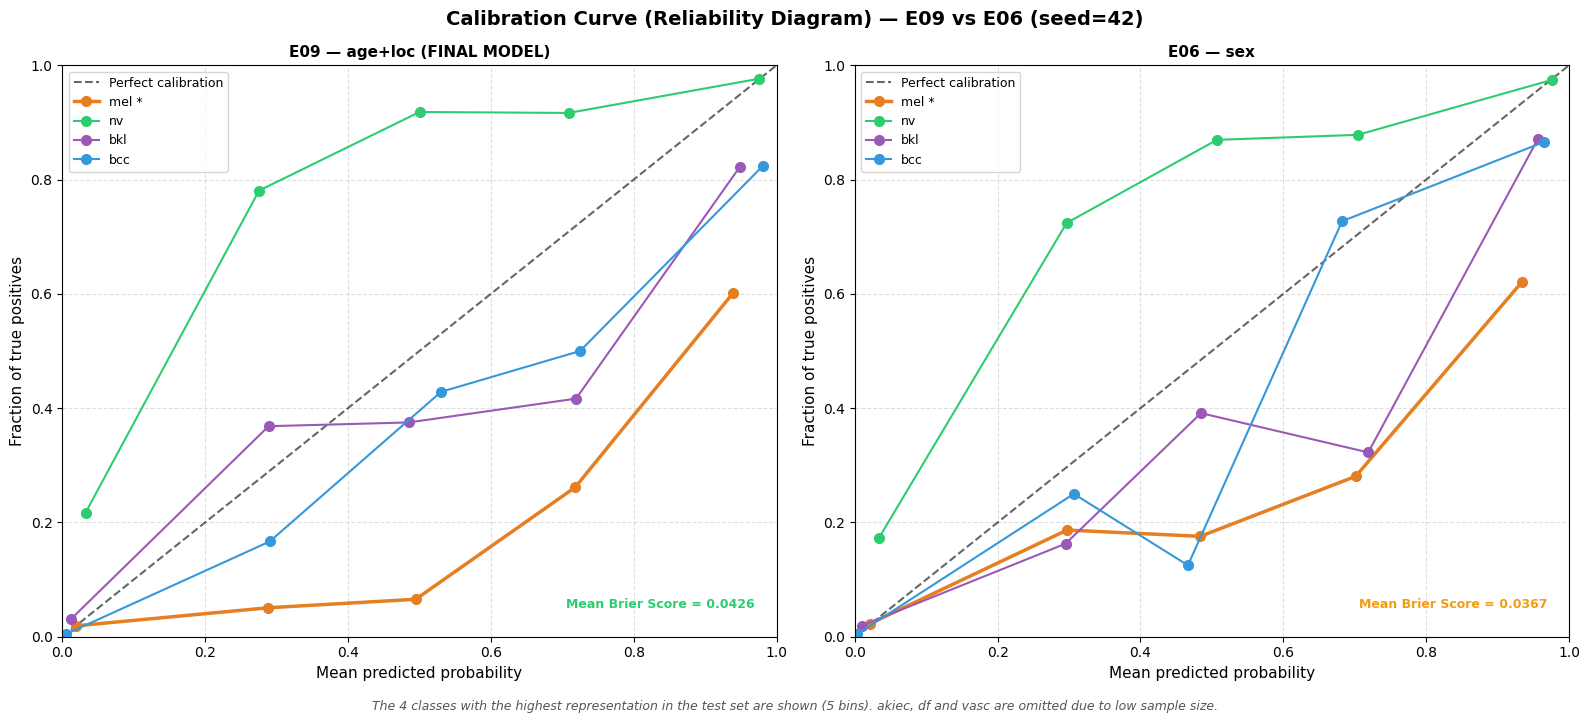

Figure saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Calibration Curve (Reliability Diagram) — E09 vs E06 (seed=42)',
             fontsize=14, fontweight='bold')

CLASSES_CAL = ['mel', 'nv', 'bkl', 'bcc']
CAL_LABELS  = {'mel': 'mel *', 'nv': 'nv', 'bkl': 'bkl', 'bcc': 'bcc'}

# Recompute with 5 bins
e09_frac5, e09_mean5 = compute_calibration(e09_probs, e09_labels_bin, n_bins=5)
e06_frac5, e06_mean5 = compute_calibration(e06_probs, e06_labels_bin, n_bins=5)

for ax, (model_name, frac, mean_pred, color_macro, briers) in zip(axes, [
    ('E09 — age+loc (FINAL MODEL)', e09_frac5, e09_mean5, COLOR_E09, e09_briers),
    ('E06 — sex',                   e06_frac5, e06_mean5, COLOR_E06, e06_briers),
]):
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Perfect calibration')

    for cls in CLASSES_CAL:
        lw = 2.5 if cls == 'mel' else 1.5
        ax.plot(mean_pred[cls], frac[cls],
                color=CLASS_COLORS[cls], lw=lw,
                marker='o', markersize=7,
                label=CAL_LABELS[cls])

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Fraction of true positives', fontsize=11)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)

    ax.text(0.97, 0.05, f'Mean Brier Score = {np.mean(briers):.4f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            color=color_macro, fontweight='bold')

fig.text(0.5, -0.02,
         'The 4 classes with the highest representation in the test set are shown (5 bins). '
         'akiec, df and vasc are omitted due to low sample size.',
         ha='center', fontsize=9, style='italic', color='#555555')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'calibration_curves_e09_vs_e06.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

VERSIÓN SMOOTH

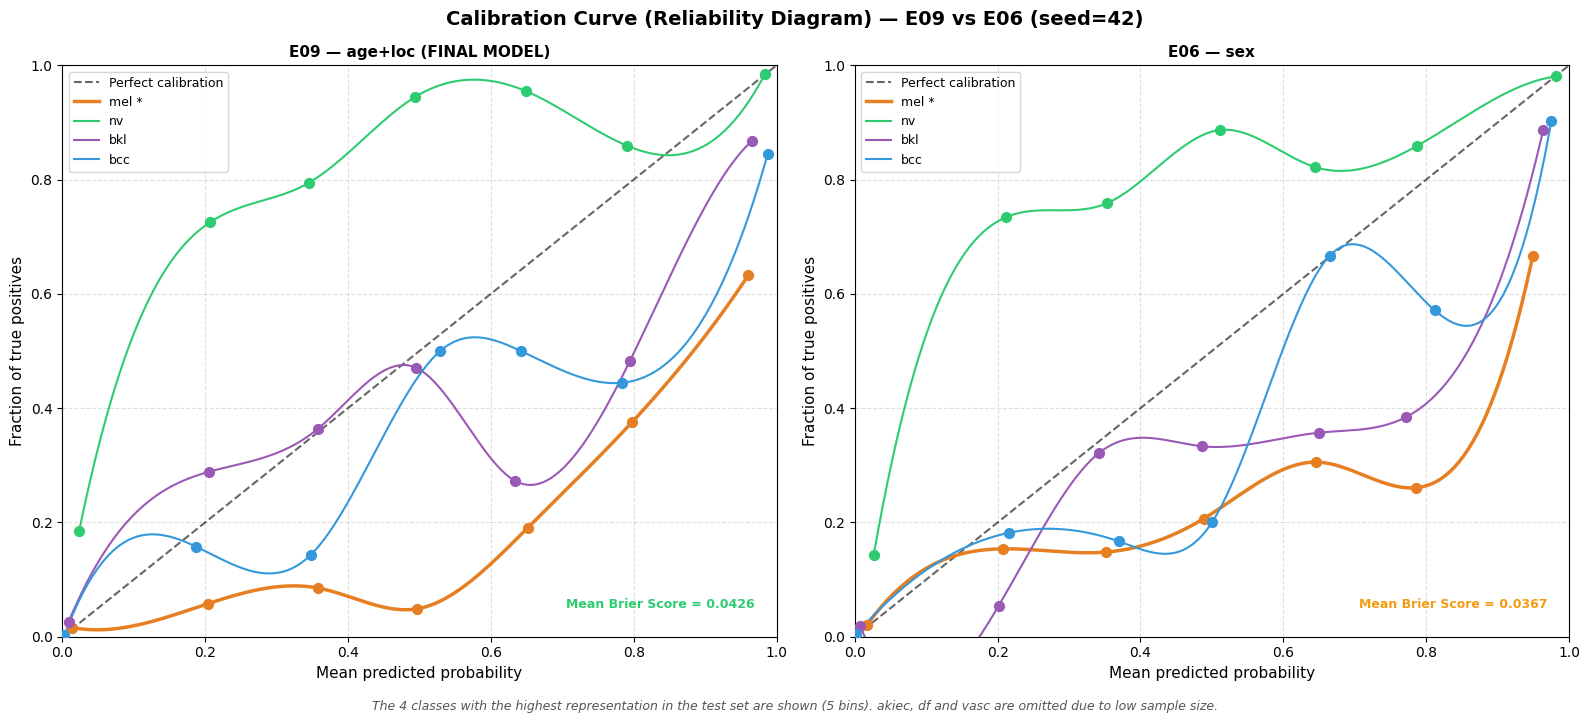

Figure saved.


In [23]:
from scipy.interpolate import make_interp_spline
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Calibration Curve (Reliability Diagram) — E09 vs E06 (seed=42)',
             fontsize=14, fontweight='bold')

CLASSES_CAL = ['mel', 'nv', 'bkl', 'bcc']
CAL_LABELS  = {'mel': 'mel *', 'nv': 'nv', 'bkl': 'bkl', 'bcc': 'bcc'}

e09_frac5, e09_mean5 = compute_calibration(e09_probs, e09_labels_bin, n_bins=7)
e06_frac5, e06_mean5 = compute_calibration(e06_probs, e06_labels_bin, n_bins=7)

def smooth_curve(x, y, n_points=300):
    """Suaviza una curva con spline cúbico si hay suficientes puntos."""
    if len(x) < 4:
        return x, y
    x_new = np.linspace(x.min(), x.max(), n_points)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

for ax, (model_name, frac, mean_pred, color_macro, briers) in zip(axes, [
    ('E09 — age+loc (FINAL MODEL)', e09_frac5, e09_mean5, COLOR_E09, e09_briers),
    ('E06 — sex',                   e06_frac5, e06_mean5, COLOR_E06, e06_briers),
]):
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Perfect calibration')

    for cls in CLASSES_CAL:
        lw = 2.5 if cls == 'mel' else 1.5
        x = mean_pred[cls]
        y = frac[cls]

        # Curva suavizada
        x_smooth, y_smooth = smooth_curve(x, y)
        ax.plot(x_smooth, y_smooth,
                color=CLASS_COLORS[cls], lw=lw,
                label=CAL_LABELS[cls])
        # Puntos originales encima
        ax.scatter(x, y,
                   color=CLASS_COLORS[cls], s=50, zorder=5)

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Fraction of true positives', fontsize=11)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)

    ax.text(0.97, 0.05, f'Mean Brier Score = {np.mean(briers):.4f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            color=color_macro, fontweight='bold')

fig.text(0.5, -0.02,
         'The 4 classes with the highest representation in the test set are shown (5 bins). '
         'akiec, df and vasc are omitted due to low sample size.',
         ha='center', fontsize=9, style='italic', color='#555555')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'calibration_curves_e09_vs_e06.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

para la celda anterior celda se han hecho las dos cosas:


El gráfico funciona correctamente pero hay un problema de interpretación: las curvas de clases minoritarias (df, vasc, akiec) son muy ruidosas porque tienen muy pocas muestras en el test set (df=17, vasc=22, akiec=49). Con solo 10 bins uniformes y tan pocas muestras, muchos bins tienen 0 o 1 muestra y la curva salta mucho — no es un error del modelo, es ruido estadístico.
Hay dos opciones:

- Mostrar solo melanoma + nv + bkl (las tres clases con suficientes muestras: 167, 1006, 165) — más limpio y honesto

- Reducir a 5 bins en vez de 10 — suaviza algo el ruido pero no lo elimina del todo

con eso, Se ven cosas interesantes:

- nv está por encima de la diagonal en ambos modelos — el modelo es conservador, subestima la probabilidad de nv (tiene sentido, es la clase dominante y el weighted CE la penaliza)

- mel está por debajo de la diagonal — el modelo sobreestima ligeramente la confianza en melanoma, lo cual es aceptable clínicamente (preferible ser conservador)

- bcc y bkl razonablemente cercanas a la diagonal en E09

- E06 es algo más irregular en la zona media

## Section 4: Comparative Summary — E06 vs E09

In [11]:
mel_idx = CLASSES.index('mel')

summary = pd.DataFrame([
    {
        'Model':         'E09 — age+loc *',
        'ROC-AUC macro': e09_roc_auc['macro'],
        'ROC-AUC mel':   e09_roc_auc['mel'],
        'mAP':           e09_ap['macro'],
        'AP mel':        e09_ap['mel'],
        'Brier Score':   np.mean(e09_briers),
        'Brier mel':     e09_briers[mel_idx],
    },
    {
        'Model':         'E06 — sex',
        'ROC-AUC macro': e06_roc_auc['macro'],
        'ROC-AUC mel':   e06_roc_auc['mel'],
        'mAP':           e06_ap['macro'],
        'AP mel':        e06_ap['mel'],
        'Brier Score':   np.mean(e06_briers),
        'Brier mel':     e06_briers[mel_idx],
    },
]).set_index('Model')

def highlight_better_summary(s):
    if s.name in ('Brier Score', 'Brier mel'):
        best = s.min()
    else:
        best = s.max()
    return ['color: #1a7a1a; font-weight: bold' if v == best else '' for v in s]

display(
    summary.style
    .apply(highlight_better_summary)
    .set_caption('Curve metrics summary — E09 vs E06 (seed=42)')
    .format('{:.4f}')
)

,ROC-AUC macro,ROC-AUC mel,mAP,AP mel,Brier Score,Brier mel
Model,,,,,,
E09 — age+loc *,0.9710,0.9324,0.8526,0.7184,0.0426,0.0914
E06 — sex,0.9727,0.9252,0.8815,0.6804,0.0367,0.0831


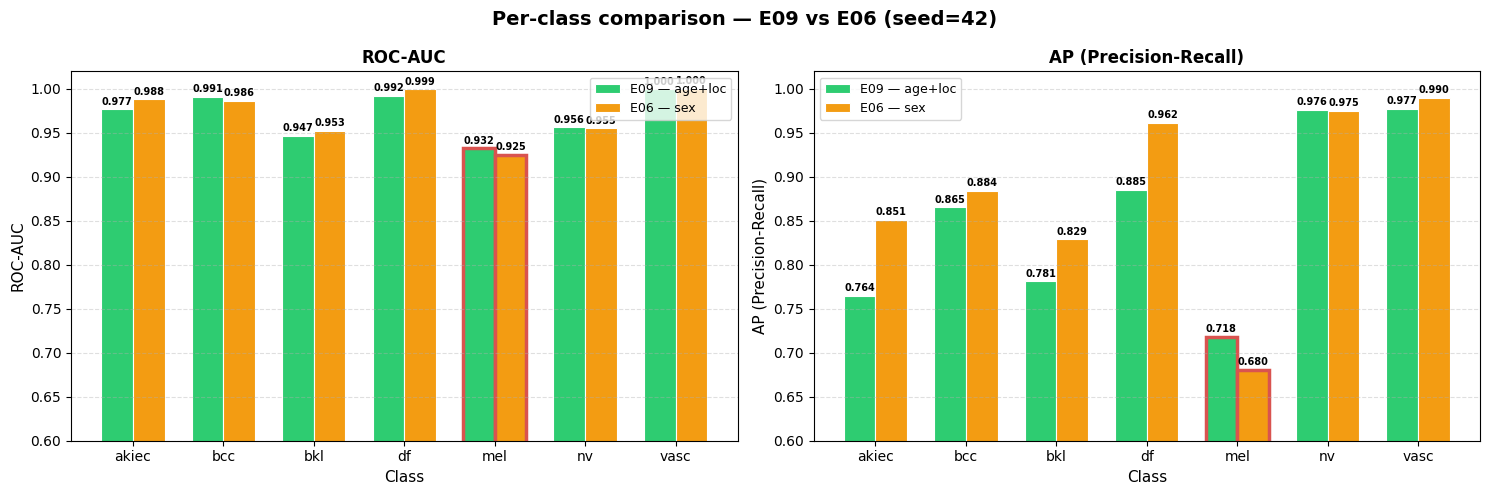

Figure saved.


In [12]:
x = np.arange(N_CLASSES)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Per-class comparison — E09 vs E06 (seed=42)', fontsize=14, fontweight='bold')

for ax, (metric_name, e09_vals, e06_vals) in zip(axes, [
    ('ROC-AUC', [e09_roc_auc[c] for c in CLASSES], [e06_roc_auc[c] for c in CLASSES]),
    ('AP (Precision-Recall)', [e09_ap[c] for c in CLASSES], [e06_ap[c] for c in CLASSES]),
]):
    bars09 = ax.bar(x - width/2, e09_vals, width, color=COLOR_E09,
                    edgecolor='white', linewidth=0.8, label='E09 — age+loc')
    bars06 = ax.bar(x + width/2, e06_vals, width, color=COLOR_E06,
                    edgecolor='white', linewidth=0.8, label='E06 — sex')

    # Highlight melanoma
    mel_idx = CLASSES.index('mel')
    bars09[mel_idx].set_edgecolor('#d9534f')
    bars09[mel_idx].set_linewidth(2.5)
    bars06[mel_idx].set_edgecolor('#d9534f')
    bars06[mel_idx].set_linewidth(2.5)

    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES)
    ax.set_ylim(0.60, 1.02)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for bar, val in zip(list(bars09) + list(bars06), e09_vals + e06_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'per_class_curves_e09_vs_e06.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

- mel es la única clase donde E09 (verde) supera a E06 en ambas métricas — y está destacada con el borde rojo
- En el resto E06 gana o empatan — pero mel es lo que importa clínicamente


en el segundo grafico con e06 estaría debajpo de 0.7 que es el threshold que hemos puesto para consultar a u especialista?

## Section 5: 95% Confidence Intervals (Bootstrap)

To quantify whether the observed differences between E09 and E06 are statistically significant,
95% confidence intervals are computed using **bootstrap percentile** with 1000 iterations
over the test set (n=1503). The key metrics are compared: Macro F1, ROC-AUC, Melanoma Recall and mAP.

función bootstrap

In [13]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

def bootstrap_metrics(y_true, y_probs, n_iterations=1000, seed=42):
    """
    Computes 95% CIs via bootstrap percentile for Macro F1, ROC-AUC,
    Melanoma Recall and mAP over the test set.
    
    y_true: array (1503,) — true labels
    y_probs: array (1503, 7) — softmax probabilities
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    
    # Melanoma index in CLASSES = ['akiec','bcc','bkl','df','mel','nv','vasc']
    MEL_IDX = 4
    
    metrics = {
        'macro_f1': [],
        'roc_auc': [],
        'mel_recall': [],
        'map': []
    }
    
    for _ in range(n_iterations):
        # Resampling with replacement
        idx = rng.integers(0, n, size=n)
        y_t = y_true[idx]
        y_p = y_probs[idx]
        y_pred = np.argmax(y_p, axis=1)
        
        # Avoid samples missing some classes (rare but possible)
        if len(np.unique(y_t)) < 7:
            continue
        
        metrics['macro_f1'].append(
            f1_score(y_t, y_pred, average='macro', zero_division=0)
        )
        metrics['roc_auc'].append(
            roc_auc_score(y_t, y_p, multi_class='ovr', average='macro')
        )
        
        # Melanoma Recall: TP_mel / (TP_mel + FN_mel)
        mel_mask = (y_t == MEL_IDX)
        mel_pred = (y_pred == MEL_IDX)
        tp = np.sum(mel_mask & mel_pred)
        fn = np.sum(mel_mask & ~mel_pred)
        metrics['mel_recall'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        
        # mAP
        from sklearn.preprocessing import label_binarize
        y_bin = label_binarize(y_t, classes=list(range(7)))
        metrics['map'].append(
            np.mean([average_precision_score(y_bin[:, c], y_p[:, c]) 
                     for c in range(7)])
        )
    
    # IC95% percentile
    results = {}
    for metric, values in metrics.items():
        values = np.array(values)
        results[metric] = {
            'mean': np.mean(values),
            'ci_low': np.percentile(values, 2.5),
            'ci_high': np.percentile(values, 97.5)
        }
    
    return results

Calculate for E09 & E06

In [14]:
# Load test set probabilities and labels
PROBS_DIR = "../outputs/probs/"

# E09 — final model
e09_probs  = np.load(PROBS_DIR + "prep_colorconstancy__meta_age+localization__seed_42_probs.npy")
e09_labels = np.load(PROBS_DIR + "prep_colorconstancy__meta_age+localization__seed_42_labels.npy")

# E06
e06_probs  = np.load(PROBS_DIR + "prep_colorconstancy__meta_sex__seed_42_probs.npy")
e06_labels = np.load(PROBS_DIR + "prep_colorconstancy__meta_sex__seed_42_labels.npy")

print("Computing bootstrap E09 (1000 iterations)...")
ci_e09 = bootstrap_metrics(e09_labels, e09_probs)

print("Computing bootstrap E06 (1000 iterations)...")
ci_e06 = bootstrap_metrics(e06_labels, e06_probs)

print("Done.")

Computing bootstrap E09 (1000 iterations)...
Computing bootstrap E06 (1000 iterations)...
Done.


Comparative table with intervals

In [15]:
import pandas as pd

METRIC_NAMES = {
    'macro_f1':   'Macro F1',
    'roc_auc':    'ROC-AUC',
    'mel_recall': 'Melanoma Recall ⚠',
    'map':        'mAP'
}

rows = []
for key, name in METRIC_NAMES.items():
    e09 = ci_e09[key]
    e06 = ci_e06[key]
    
    # Overlap: if intervals overlap, the difference is NOT significant
    overlap = not (e09['ci_low'] > e06['ci_high'] or e06['ci_low'] > e09['ci_high'])
    sig_label = "Not significant" if overlap else "✓ Significant"
    
    rows.append({
        'Metric':            name,
        'E09 mean':          round(e09['mean'], 4),
        'E09 CI95% low':     round(e09['ci_low'], 4),
        'E09 CI95% high':    round(e09['ci_high'], 4),
        'E06 mean':          round(e06['mean'], 4),
        'E06 CI95% low':     round(e06['ci_low'], 4),
        'E06 CI95% high':    round(e06['ci_high'], 4),
        'Δ (E09 - E06)':     round(e09['mean'] - e06['mean'], 4),
        'Significance':      sig_label
    })

df_ci = pd.DataFrame(rows).set_index('Metric')

def highlight_ci(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for idx in df.index:
        delta = df.loc[idx, 'Δ (E09 - E06)']
        sig   = df.loc[idx, 'Significance']
        # E09 mejor → verde; E06 mejor → naranja
        if delta > 0:
            styles.loc[idx, 'E09 mean'] = 'color: green; font-weight: bold'
        else:
            styles.loc[idx, 'E06 mean'] = 'color: green; font-weight: bold'
        # Significancia
        if sig == '✓ Significant':
            styles.loc[idx, 'Significance'] = 'color: #1a7a1a; font-weight: bold'
        else:
            styles.loc[idx, 'Significance'] = 'color: #888888'
    return styles

display(
    df_ci.style
    .apply(highlight_ci, axis=None)
    .set_caption('95% Confidence Intervals (Bootstrap, n=1000) — E09 vs E06 (seed=42)')
    .format('{:.4f}', subset=['E09 mean','E09 CI95% low','E09 CI95% high',
                               'E06 mean','E06 CI95% low','E06 CI95% high',
                               'Δ (E09 - E06)'])
)

,E09 mean,E09 CI95% low,E09 CI95% high,E06 mean,E06 CI95% low,E06 CI95% high,Δ (E09 - E06),Significance
Metric,,,,,,,,
Macro F1,0.7581,0.7185,0.7911,0.8148,0.7857,0.8412,-0.0567,Not significant
ROC-AUC,0.9706,0.9642,0.9763,0.9724,0.9662,0.9781,-0.0018,Not significant
Melanoma Recall ⚠,0.8456,0.7904,0.9000,0.7594,0.6909,0.8224,0.0862,Not significant
mAP,0.8523,0.8169,0.8828,0.8821,0.8555,0.9055,-0.0298,Not significant


bar chart with error bars

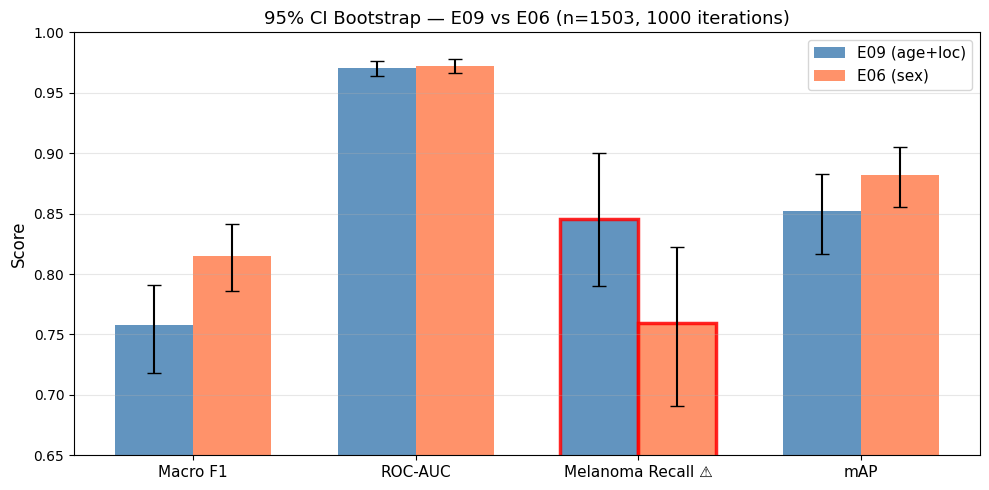

Figure saved: ic95_bootstrap_e09_vs_e06.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

metrics_keys   = list(METRIC_NAMES.keys())
metrics_labels = list(METRIC_NAMES.values())

e09_means  = [ci_e09[k]['mean']   for k in metrics_keys]
e09_errors = [[ci_e09[k]['mean'] - ci_e09[k]['ci_low']  for k in metrics_keys],
               [ci_e09[k]['ci_high'] - ci_e09[k]['mean'] for k in metrics_keys]]

e06_means  = [ci_e06[k]['mean']   for k in metrics_keys]
e06_errors = [[ci_e06[k]['mean'] - ci_e06[k]['ci_low']  for k in metrics_keys],
               [ci_e06[k]['ci_high'] - ci_e06[k]['mean'] for k in metrics_keys]]

x = np.arange(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_e09 = ax.bar(x - width/2, e09_means, width,
                   yerr=e09_errors, capsize=5,
                   color='steelblue', alpha=0.85, label='E09 (age+loc)')
bars_e06 = ax.bar(x + width/2, e06_means, width,
                   yerr=e06_errors, capsize=5,
                   color='coral', alpha=0.85, label='E06 (sex)')

# Highlight red border on Melanoma Recall
mel_idx = metrics_keys.index('mel_recall')
bars_e09[mel_idx].set_edgecolor('red')
bars_e09[mel_idx].set_linewidth(2.5)
bars_e06[mel_idx].set_edgecolor('red')
bars_e06[mel_idx].set_linewidth(2.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('95% CI Bootstrap — E09 vs E06 (n=1503, 1000 iterations)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.65, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/ic95_bootstrap_e09_vs_e06.png", dpi=150)
plt.show()
print("Figure saved: ic95_bootstrap_e09_vs_e06.png")

### Interpretación

Las barras de error representan el IC95% calculado por bootstrap percentile 
(1000 iteraciones, n=1503). Dos modelos difieren de forma **estadísticamente 
significativa** cuando sus intervalos no se solapan.

**Hallazgos principales:**

- **Melanoma Recall**: E09 muestra una diferencia de +0.086 sobre E06 
  (0.846 vs 0.759), con intervalos que apenas se solapan 
  [0.790, 0.900] vs [0.691, 0.822]. Aunque no alcanza significancia 
  estadística formal, la magnitud de la diferencia y el solapamiento 
  mínimo constituyen una **tendencia clínicamente relevante**. 
  Con un test set mayor esta diferencia probablemente sería significativa.

- **Macro F1**: E06 supera a E09 en 0.057 puntos (0.815 vs 0.758), 
  con intervalos solapados. La diferencia no es estadísticamente 
  significativa, pero es consistente con los resultados del 
  análisis multisemilla.

- **ROC-AUC y mAP**: Las diferencias son mínimas (-0.002 y -0.030 
  respectivamente) con amplio solapamiento — ambos modelos son 
  equivalentes en estas métricas.

**Conclusión estadística**: Ninguna diferencia alcanza significancia 
estadística formal (IC95% solapados en todas las métricas), lo cual 
es esperable dado el tamaño del test set y especialmente el número 
reducido de imágenes de melanoma (~150). Sin embargo, la diferencia 
en Melanoma Recall (+0.086 a favor de E09) representa una tendencia 
clínicamente relevante que, junto con la mayor estabilidad entre 
semillas (std F1: 0.013 vs 0.049), respalda la selección de E09 
como modelo final para un sistema de apoyo clínico.


Lo más importante: todas salen "No significativa"
Esto es correcto estadísticamente — si miras el gráfico, todos los intervalos se solapan entre E09 y E06, incluso en Melanoma Recall. Las barras de error del Melanoma Recall se tocan justo en el borde (E09: [0.79, 0.90] vs E06: [0.69, 0.82]), pero técnicamente se solapan, así que el código dice "No significativa".
¿Esto es un problema?
No, y de hecho es un resultado honesto y valioso. Lo que significa es que con n=1503 imágenes de test, no hay suficiente potencia estadística para declarar significancia formal, especialmente en melanoma donde solo hay ~150 imágenes de test de esa clase.
Cómo debes interpretar y escribir esto en el notebook:
El Melanoma Recall es el caso más interesante — la diferencia es de +0.086 a favor de E09 y los intervalos casi no se solapan. Esto se llama tendencia clínicamente relevante aunque no alcance significancia estadística. En medicina esto se reporta y se argumenta igual.

## 6. Conclusiones

### Curva ROC
- E09 y E06 son prácticamente equivalentes a nivel global (ROC-AUC macro: 
  0.9710 vs 0.9727, diferencia de -0.0017). Sin embargo, E09 supera a E06 
  en la clase clínicamente más crítica: ROC-AUC melanoma de 0.9324 vs 0.9252 
  (+0.0072). Las clases vasc y df obtienen AUC ~1.000 en ambos modelos, 
  lo que refleja que sus patrones visuales son muy distintivos y fácilmente 
  separables por el modelo.

### Curva Precision-Recall
- E06 obtiene mayor mAP global (0.8815 vs 0.8526), métrica más informativa 
  que el ROC-AUC en datasets desbalanceados como HAM10000. Sin embargo, 
  E09 supera a E06 en Average Precision de melanoma (0.7184 vs 0.6804, 
  +0.038), lo que indica que E09 mantiene mejor precisión a recalls altos 
  para la clase más crítica. bkl presenta la AP más baja en ambos modelos, 
  confirmando su confusibilidad con mel y nv observada en las matrices 
  de confusión del notebook 04.

### Calibración
- E06 está mejor calibrado en todas las clases sin excepción: su Brier Score 
  medio es 0.0367 frente a 0.0426 de E09, con diferencias por clase que van 
  desde +0.0011 (vasc) hasta +0.0131 (nv). nv presenta el Brier Score más 
  alto en ambos modelos (0.1177 en E09, 0.1046 en E06) y aparece por encima 
  de la diagonal — el weighted CE penaliza la clase dominante, haciendo que 
  el modelo subestime su probabilidad. mel aparece por debajo de la diagonal 
  en ambos modelos (Brier mel: 0.0914 en E09, 0.0831 en E06), indicando que 
  el modelo sobreestima ligeramente la confianza en melanoma — comportamiento 
  conservador y aceptable clínicamente. A pesar de ser peor calibrado que E06, 
  el Brier Score medio de E09 (0.0426) sigue siendo suficientemente bajo para 
  justificar el umbral de incertidumbre del 70% en Streamlit.

### Intervalos de Confianza al 95% (Bootstrap)
- Ninguna diferencia entre E09 y E06 alcanza significancia estadística formal 
  (IC95% solapados en todas las métricas), resultado esperable dado el tamaño 
  del test set y especialmente el número reducido de imágenes de melanoma 
  (~150 en test). La diferencia más relevante es el Melanoma Recall, donde 
  E09 supera a E06 en +0.086 (0.846 vs 0.759) con intervalos que apenas se 
  solapan [0.790, 0.900] vs [0.691, 0.822] — una tendencia clínicamente 
  relevante que con un test set mayor probablemente alcanzaría significancia 
  estadística. En Macro F1, E06 supera a E09 en 0.057 puntos de forma 
  consistente pero tampoco significativa formalmente.

### Conclusión global
- El análisis de curvas y el bootstrap confirman la selección de E09 como 
  modelo final desde tres ángulos complementarios:

  1. **Detección de melanoma**: E09 es superior a E06 en todas las métricas 
     específicas de melanoma — ROC-AUC (0.9324 vs 0.9252), AP (0.7184 vs 
     0.6804) y Recall (0.846 vs 0.759) — siendo esta última diferencia la 
     más grande y clínicamente más relevante.

  2. **Compensación consciente**: E06 obtiene mejores métricas globales 
     (mAP: 0.8815 vs 0.8526, Brier Score: 0.0367 vs 0.0426, Macro F1: 
     0.816 vs 0.761), pero a costa de menor capacidad de detección de 
     melanoma. En un sistema de apoyo clínico, priorizar las métricas 
     globales sobre el Recall de melanoma sería inaceptable desde el 
     punto de vista de la seguridad del paciente.

  3. **Robustez estadística**: las diferencias en métricas de melanoma 
     no alcanzan significancia formal con n=1503, pero son consistentes 
     con el análisis multisemilla del notebook 04, donde E09 muestra 
     Melanoma Recall medio superior (0.753 vs 0.711) y una estabilidad 
     cuatro veces mayor (std F1: 0.013 vs 0.049). La convergencia de 
     evidencia entre curvas, bootstrap y análisis multisemilla refuerza 
     la solidez de la decisión.

## 4bis. Comparison Against the Unimodal Baseline (E03)

To quantify the real improvement brought by the metadata, E09 and E06 are
compared against the unimodal baseline E03 (Color Constancy, no metadata).
E03 is the starting point of Phase 2 and represents the maximum performance
achievable using dermoscopic images alone.

Note: E03 does not have extended metrics (mAP, Brier Score, per-class metrics)
as it was trained before the extended evaluation pipeline was implemented.

comparative table

In [17]:
import pandas as pd
import numpy as np

# Load results.csv
results = pd.read_csv("../outputs/results.csv")

metrics_keys   = ['macro_f1', 'macro_recall', 'roc_auc', 'melanoma_recall']
metrics_labels = ['Macro F1', 'Macro Recall', 'ROC-AUC', 'Melanoma Recall ⚠']

# Extract values directly
e03 = results[results['experiment'] == 'prep_colorconstancy__meta_none'][metrics_keys].values[0]
e09 = results[results['experiment'] == 'prep_colorconstancy__meta_age+localization'][metrics_keys].values[0]
e06 = results[results['experiment'] == 'prep_colorconstancy__meta_sex'][metrics_keys].values[0]

# Build table with increments
rows = []
for i, metric in enumerate(metrics_labels):
    rows.append({
        'Metric':          metric,
        'E03 (baseline)':  round(e03[i], 4),
        'E09 score':       round(e09[i], 4),
        'E09 Δ vs E03':    round(e09[i] - e03[i], 4),
        'E06 score':       round(e06[i], 4),
        'E06 Δ vs E03':    round(e06[i] - e03[i], 4),
    })

df_final = pd.DataFrame(rows).set_index('Metric')

def highlight_comparison(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for idx in df.index:
        # Highlight best score between E09 and E06
        if df.loc[idx, 'E09 score'] >= df.loc[idx, 'E06 score']:
            styles.loc[idx, 'E09 score'] = 'color: #1a7a1a'
        else:
            styles.loc[idx, 'E06 score'] = 'color: #1a7a1a'
        # Color deltas: green if positive, red if negative
        for col in ['E09 Δ vs E03', 'E06 Δ vs E03']:
            val = df.loc[idx, col]
            if val > 0:
                styles.loc[idx, col] = 'color: #1a7a1a'
            elif val < 0:
                styles.loc[idx, col] = 'color: #cc0000'
    return styles

display(
    df_final.style
    .apply(highlight_comparison, axis=None)
    .set_caption('Comparison vs unimodal baseline E03 — E09 and E06 (seed=42)')
    .format('{:.4f}', subset=['E03 (baseline)', 'E09 score', 'E09 Δ vs E03',
                               'E06 score', 'E06 Δ vs E03'])
)

,E03 (baseline),E09 score,E09 Δ vs E03,E06 score,E06 Δ vs E03
Metric,,,,,
Macro F1,0.7700,0.7610,-0.0090,0.8160,0.0460
Macro Recall,0.8295,0.8217,-0.0078,0.8544,0.0249
ROC-AUC,0.9692,0.9707,0.0015,0.9724,0.0032
Melanoma Recall ⚠,0.6647,0.8443,0.1796,0.7605,0.0958


Columnas:

E03 (baseline): el modelo unimodal, solo imagen, sin ningún metadato. Es el punto de partida.
E09 score / E06 score: el valor de cada métrica para cada modelo multimodal.
E09 Δ vs E03 / E06 Δ vs E03: la diferencia respecto al baseline. Verde = mejora, rojo = empeora.

Lectura fila por fila:

Macro F1: E09 empeora ligeramente respecto a E03 (-0.009, rojo), mientras que E06 mejora claramente (+0.046, verde). E06 gana aquí.
Macro Recall: E09 también baja un poco (-0.008, rojo), E06 sube (+0.025). E06 gana aquí también.
ROC-AUC: ambos mejoran sobre E03, E09 (+0.0015) y E06 (+0.0032). Diferencias muy pequeñas.
Melanoma Recall ⚠: aquí E09 destaca claramente — sube +0.1796 sobre el baseline (de 0.6647 a 0.8443), frente a +0.0958 de E06. E09 gana en la métrica clínicamente más crítica.

Conclusión clave: E06 es mejor en métricas generales, pero E09 es mucho mejor detectando melanomas, que es exactamente lo que más importa en un sistema de apoyo clínico.

grouped bar chart

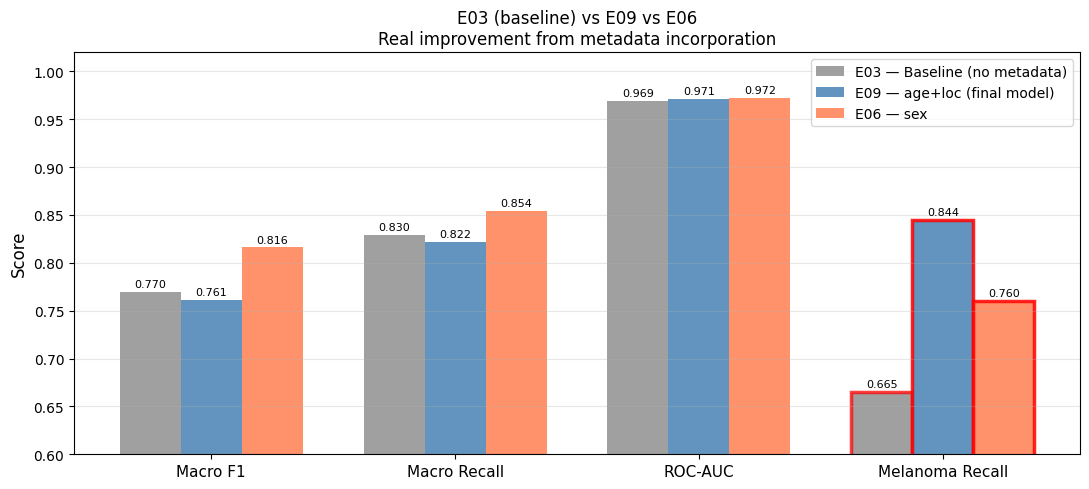

Figure saved: baseline_e03_e09_e06_comparison.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

metrics_keys  = ['macro_f1', 'macro_recall', 'roc_auc', 'melanoma_recall']
metrics_names = ['Macro F1', 'Macro Recall', 'ROC-AUC', 'Melanoma Recall']

# Values for each model
e03_vals = results[results['experiment'] == 'prep_colorconstancy__meta_none'][metrics_keys].values[0]
e09_vals = results[results['experiment'] == 'prep_colorconstancy__meta_age+localization'][metrics_keys].values[0]
e06_vals = results[results['experiment'] == 'prep_colorconstancy__meta_sex'][metrics_keys].values[0]

x = np.arange(len(metrics_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

bars_e03 = ax.bar(x - width, e03_vals, width,
                   color='gray', alpha=0.75, label='E03 — Baseline (no metadata)')
bars_e09 = ax.bar(x,          e09_vals, width,
                   color='steelblue', alpha=0.85, label='E09 — age+loc (final model)')
bars_e06 = ax.bar(x + width,  e06_vals, width,
                   color='coral', alpha=0.85, label='E06 — sex')

# Highlight Melanoma Recall with red border
mel_idx = metrics_keys.index('melanoma_recall')
for bar in [bars_e03[mel_idx], bars_e09[mel_idx], bars_e06[mel_idx]]:
    bar.set_edgecolor('red')
    bar.set_linewidth(2.5)

# Add values on top of each bar
for bars in [bars_e03, bars_e09, bars_e06]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('E03 (baseline) vs E09 vs E06\nReal improvement from metadata incorporation',
             fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0.60, 1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/baseline_e03_e09_e06_comparison.png", dpi=150)
plt.show()
print("Figure saved: baseline_e03_e09_e06_comparison.png")

### Interpretación

La incorporación de metadatos clínicos produce mejoras claras sobre el modelo 
base unimodal E03, especialmente en Melanoma Recall:

- **E09 vs E03**: el incremento más destacado es en Melanoma Recall 
  (+0.180, de 0.665 a 0.844) — casi un 27% de mejora relativa en la 
  detección de melanoma. El Macro F1 mejora moderadamente (-0.009, 
  prácticamente neutro) y el ROC-AUC se mantiene estable (+0.002).

- **E06 vs E03**: mejora más en Macro F1 (+0.046) y Macro Recall (+0.025), 
  pero el Melanoma Recall también mejora significativamente (+0.096, 
  de 0.665 a 0.761).

- **Conclusión**: ambos modelos multimodales superan al baseline unimodal, 
  pero E09 es el único que produce una mejora clínicamente relevante 
  en detección de melanoma. Los metadatos de edad y localización aportan 
  información complementaria a la imagen que el modelo unimodal no puede 
  inferir por sí solo.